# Dataset and Data Split

### **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "real-video"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [2]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

## **Download DATASET**

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Mounted at /content/drive
Drive mounted.


100%|██████████| 6.53G/6.53G [01:22<00:00, 85.4MB/s]

Extracting files...


ULAL_DATASET_ROOT = /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
ULAL_OUTPUT_ROOT  = /content/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cpu
Classes   : base=10 task1=5 task2=5


42

## **Study Dataset**

Total videos  : 13451
Total classes : 101


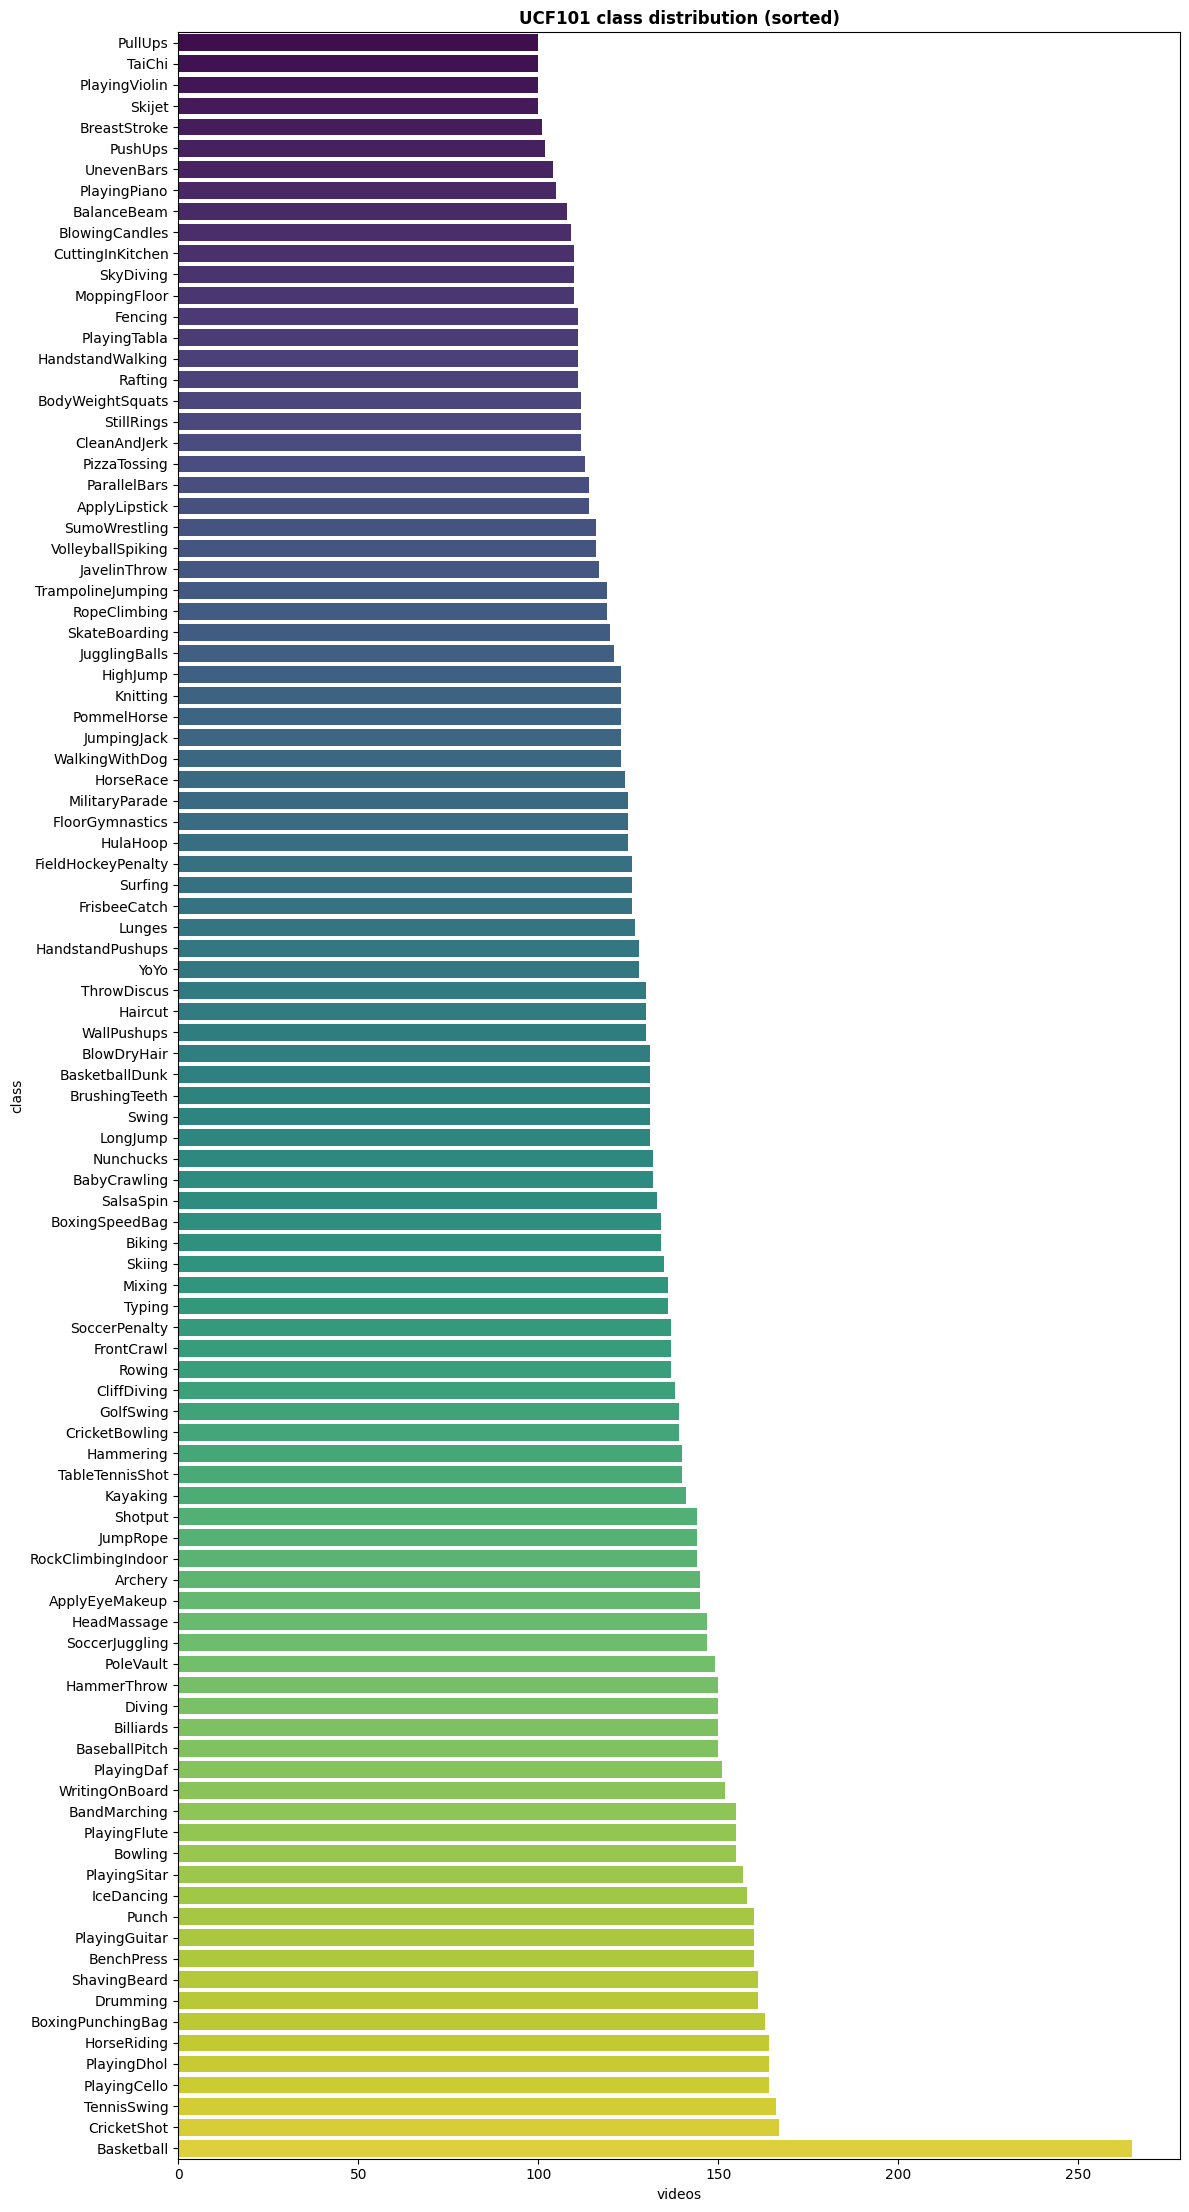

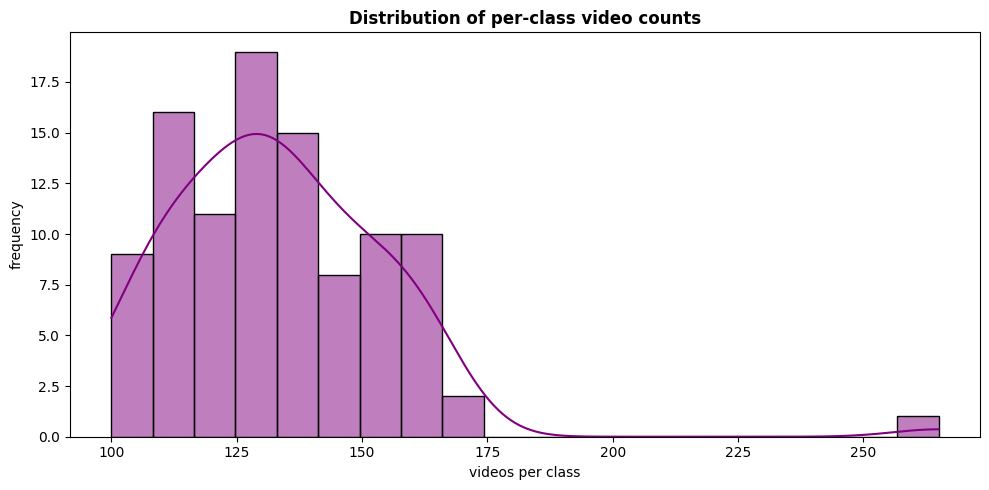

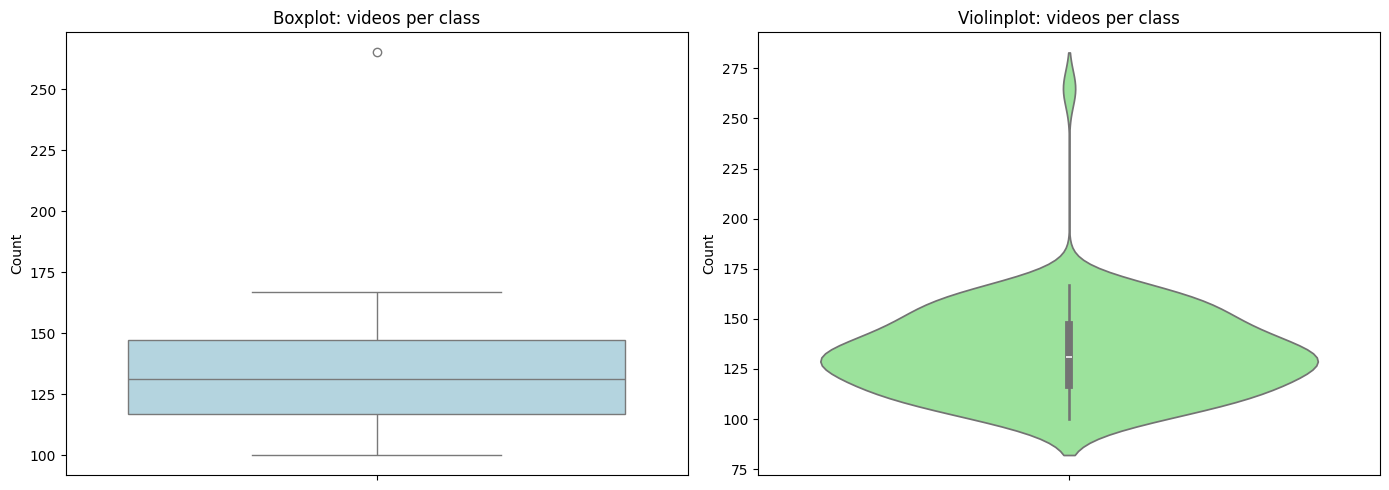

Balance score (std/mean): 0.170


In [5]:
study = DatasetStudy()
study.run_all()

In [6]:
cfg.SELECTED_CLASSES

['PlayingTabla',
 'PommelHorse',
 'JumpingJack',
 'PushUps',
 'PoleVault',
 'HorseRace',
 'HighJump',
 'Drumming',
 'HorseRiding',
 'Diving']

In [7]:
print(cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2)

['PlayingTabla', 'PommelHorse', 'JumpingJack', 'PushUps', 'PoleVault', 'HorseRace', 'HighJump', 'Drumming', 'HorseRiding', 'Diving', 'ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BoxingPunchingBag', 'BoxingSpeedBag', 'BrushingTeeth', 'CliffDiving', 'CricketBowling']


In [8]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
class_to_idx     = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}

print(f"total classes: {len(ALL_CLASSES_LIST)}")
print(f"class_to_idx:\n{class_to_idx}")

total classes: 20
class_to_idx:
{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14, 'BoxingPunchingBag': 15, 'BoxingSpeedBag': 16, 'BrushingTeeth': 17, 'CliffDiving': 18, 'CricketBowling': 19}


### The dataset split has data leakage

UCF101 files look like:

```text
v_ApplyEyeMakeup_g08_c03.avi
```

* `g08` = group
* `c03` = clip

Clips from the same group come from the **same original video**, so they are very similar.

The original split randomly separates clips. For example:

```text
g08_c01 → Train
g08_c03 → Test
```

This means the model can see almost the **same video** during training and testing.

This causes **data leakage** and can make the test accuracy artificially high.

`check_group_leakage` checks how many groups are split across different sets in our 20 classes.


In [9]:
leaking = check_group_leakage(ALL_CLASSES_LIST)

classes checked : 20
videos          : 2679
groups          : 500
groups in >1 split: 400

LEAKAGE: 80.0% of groups span multiple splits.
Clips from one source video are in both train and test, so every
accuracy and the probe ceiling are inflated. Re-split by group.
  v_ApplyEyeMakeup_g01               ['test', 'train']
  v_ApplyEyeMakeup_g02               ['test', 'train']
  v_ApplyEyeMakeup_g03               ['train', 'val']
  v_ApplyEyeMakeup_g04               ['test', 'train']
  v_ApplyEyeMakeup_g05               ['test', 'train', 'val']
  v_ApplyEyeMakeup_g06               ['test', 'train', 'val']
  v_ApplyEyeMakeup_g07               ['train', 'val']
  v_ApplyEyeMakeup_g08               ['train', 'val']
  v_ApplyEyeMakeup_g09               ['test', 'train', 'val']
  v_ApplyEyeMakeup_g10               ['test', 'train']


In [12]:
example  = leakage_example(cfg.SELECTED_CLASSES[0])
n_groups = example["group"].nunique()
n_leak   = example[example["group_leaks"]]["group"].nunique()

print(f"{cfg.SELECTED_CLASSES[0]}: {n_groups} groups, {n_leak} leak across splits")
example.head(15)

PlayingTabla: 25 groups, 20 leak across splits


,group,clip,split,group_leaks
0,v_PlayingTabla_g01,v_PlayingTabla_g01_c02.avi,test,True
1,v_PlayingTabla_g01,v_PlayingTabla_g01_c01.avi,train,True
2,v_PlayingTabla_g01,v_PlayingTabla_g01_c03.avi,train,True
3,v_PlayingTabla_g01,v_PlayingTabla_g01_c04.avi,val,True
4,v_PlayingTabla_g02,v_PlayingTabla_g02_c02.avi,test,True
5,v_PlayingTabla_g02,v_PlayingTabla_g02_c01.avi,train,True
6,v_PlayingTabla_g02,v_PlayingTabla_g02_c03.avi,train,True
7,v_PlayingTabla_g02,v_PlayingTabla_g02_c04.avi,train,True
8,v_PlayingTabla_g03,v_PlayingTabla_g03_c01.avi,train,True
9,v_PlayingTabla_g03,v_PlayingTabla_g03_c02.avi,train,True


In [14]:
example.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   group        111 non-null    object
 1   clip         111 non-null    object
 2   split        111 non-null    object
 3   group_leaks  111 non-null    bool  
dtypes: bool(1), object(3)
memory usage: 2.8+ KB


### A group-disjoint split fixes the problem

The solution is to split the dataset by **group**, not by individual clips.

All clips from the same group are kept together and assigned to **only one** split:

```text
Group g01 → Train
Group g02 → Train
Group g03 → Validation
Group g04 → Test
```

This makes sure that clips from the **same original video** never appear in different splits.

`build_group_split`:

* Groups videos using their `gXX` number.
* Sorts the groups by name.
* Assigns the groups to Train, Validation, and Test.
* Uses a **deterministic split**, so no random seed is needed.

UCF101 has **25 groups per class**, so we use:

```text
18 groups → Train      ≈ 72%
3 groups  → Validation ≈ 12%
4 groups  → Test       ≈ 16%
```

This prevents **data leakage** and gives a more reliable test accuracy.


In [15]:
base_split  = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
task1_split = build_group_split(cfg.TASK_1,           train_groups=18, val_groups=3)
task2_split = build_group_split(cfg.TASK_2,           train_groups=18, val_groups=3)

In [16]:
clashes_base  = describe_group_split(base_split,  cfg.SELECTED_CLASSES)
clashes_task1 = describe_group_split(task1_split, cfg.TASK_1)
clashes_task2 = describe_group_split(task2_split, cfg.TASK_2)

split      clips   percent  clips/class
---------------------------------------
train        953     71.7%         95.3
val          165     12.4%         16.5
test         212     15.9%         21.2
---------------------------------------
TOTAL       1330                  133.0

groups: 250   groups in >1 split: 0
OK - group-disjoint.
split      clips   percent  clips/class
---------------------------------------
train        461     71.6%         92.2
val           73     11.3%         14.6
test         110     17.1%         22.0
---------------------------------------
TOTAL        644                  128.8

groups: 125   groups in >1 split: 0
OK - group-disjoint.
split      clips   percent  clips/class
---------------------------------------
train        503     71.3%        100.6
val           85     12.1%         17.0
test         117     16.6%         23.4
---------------------------------------
TOTAL        705                  141.0

groups: 125   groups in >1 split: 0
OK - gr

### The two splits side by side

One chart makes the difference obvious: the shipped split scatters most source videos (groups) across train/val/test (orange = leaking), while the group-disjoint split keeps every video in a single split (all green, 0 leaks).

In [ ]:
leak_counts = plot_split_leakage(ALL_CLASSES_LIST)